In [ ]:
!pip install tensorflow
!pip install matplotlib numpy pillow

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
🚀 Starting Model 1 Baseline...
🚀 Model 1 Progress: Epoch 9/100 | Loss: 0.0005 | Acc: 1.0000 | Val Loss: 0.1471
✅ Training Complete.
📊 Generating Metrics Dashboard...


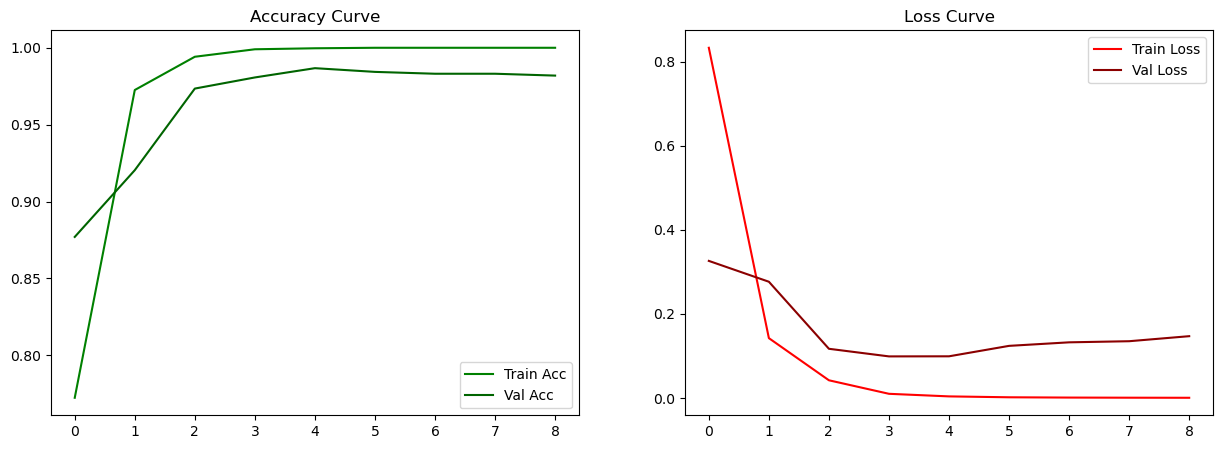

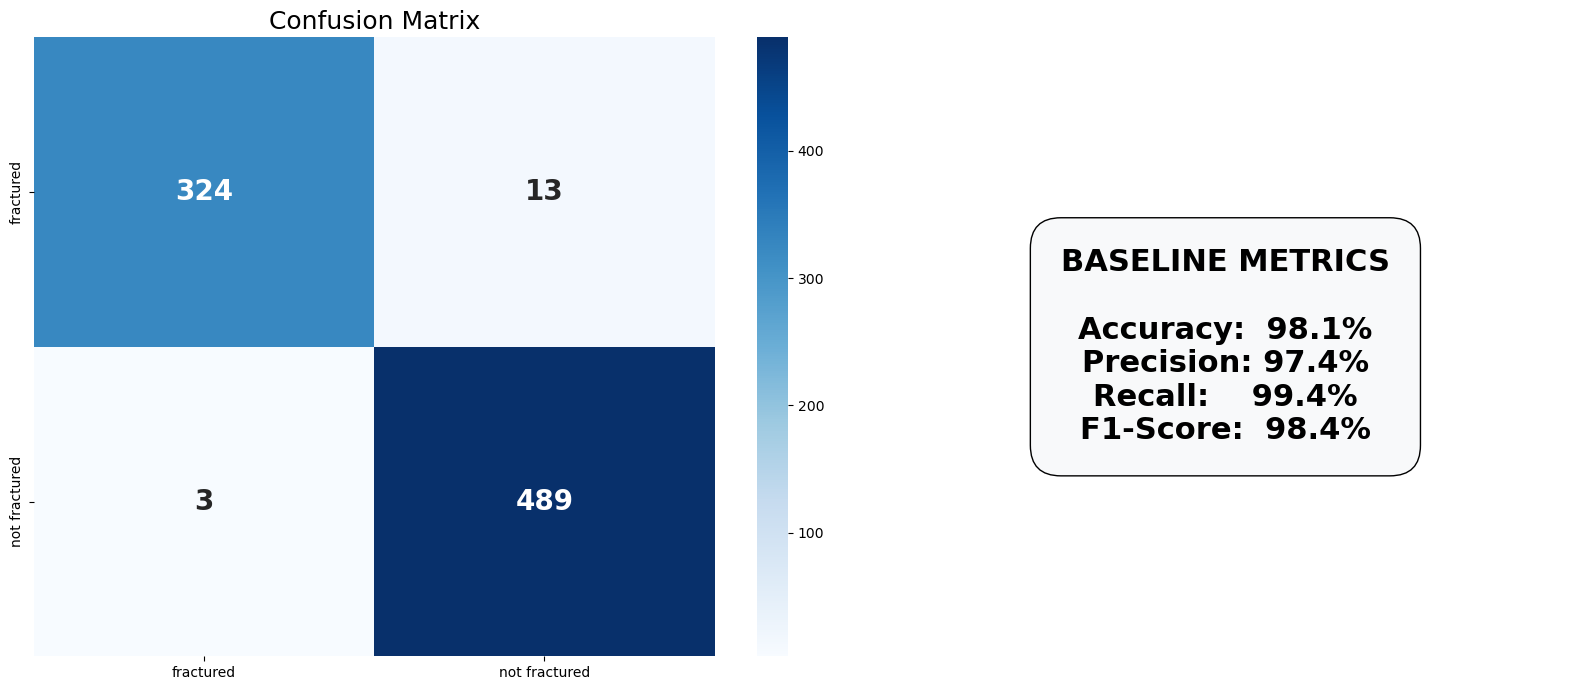

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import ImageFile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# --- 1. SYSTEM SETTINGS & SAFETY ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True 

# --- 2. PATHS ---
root_path = r'Bone Fracture\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification'
train_dir = os.path.join(root_path, 'train')
val_dir = os.path.join(root_path, 'val')

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# --- 3. SINGLE LINE PROGRESS CALLBACK ---
class CleanProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\r🚀 Model 1 Progress: Epoch {epoch+1}/{self.params['epochs']} "
              f"| Loss: {logs['loss']:.4f} | Acc: {logs['accuracy']:.4f} "
              f"| Val Loss: {logs['val_loss']:.4f}", end="")

# --- 4. DATA GENERATORS ---
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# --- 5. CLASS WEIGHTS ---
labels = (train_gen.class_indices)
f_idx = next(idx for name, idx in labels.items() if 'fracture' in name.lower())
n_idx = next(idx for name, idx in labels.items() if 'not' in name.lower() or 'normal' in name.lower())
weights = {f_idx: 5.0, n_idx: 1.0} 

# --- 6. MODEL 1 ARCHITECTURE ---
model_1 = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model_1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- 7. CALLBACKS ---
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('model_1_baseline.keras', save_best_only=True, monitor='val_loss')

# --- 8. TRAINING ---
print(f"🚀 Starting Model 1 Baseline...")
history = model_1.fit(
    train_gen, epochs=100, validation_data=val_gen,
    class_weight=weights, verbose=0, callbacks=[CleanProgress(), early_stop, checkpoint] 
)
print("\n✅ Training Complete.")

# --- 9. THE LEVEL 4 DASHBOARD (Metrics + Confusion Matrix) ---
def generate_advanced_dashboard(model, history, val_gen, labels_dict):
    print("📊 Generating Metrics Dashboard...")
    
    # 1. Plot Learning Curves
    fig_lc, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history.history['accuracy'], label='Train Acc', color='green')
    ax1.plot(history.history['val_accuracy'], label='Val Acc', color='darkgreen')
    ax1.set_title('Accuracy Curve')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Train Loss', color='red')
    ax2.plot(history.history['val_loss'], label='Val Loss', color='darkred')
    ax2.set_title('Loss Curve')
    ax2.legend()
    plt.show()

    # 2. Calculate Final Metrics
    val_gen.reset()
    preds_prob = model.predict(val_gen, verbose=0) 
    y_pred = (preds_prob > 0.5).astype(int).reshape(-1)
    y_true = val_gen.classes
    
    cm = confusion_matrix(y_true, y_pred)
    acc = (y_pred == y_true).mean()
    pre = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # 3. Plot Confusion Matrix & Metric Card
    fig_m, (ax_cm, ax_card) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.2, 1]})
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_cm, 
                xticklabels=labels_dict.keys(), yticklabels=labels_dict.keys(),
                annot_kws={"size": 20, "weight": "bold"})
    ax_cm.set_title('Confusion Matrix', fontsize=18)

    ax_card.axis('off')
    card_text = (f"BASELINE METRICS\n\n"
                 f"Accuracy:  {acc:.1%}\n"
                 f"Precision: {pre:.1%}\n"
                 f"Recall:    {rec:.1%}\n"
                 f"F1-Score:  {f1:.1%}")
    
    ax_card.text(0.5, 0.5, card_text, ha='center', va='center', fontsize=22, fontweight='bold',
                 bbox=dict(facecolor='#f8f9fa', edgecolor='black', boxstyle='round,pad=1'))
    
    plt.tight_layout()
    plt.show()

# --- 10. RUN REPORT ---
generate_advanced_dashboard(model_1, history, val_gen, labels)

Found 9246 images belonging to 2 classes.
Found 829 images belonging to 2 classes.
🚀 Starting Model 2... This may take longer but will be much smarter.
🚀 Model 2 Fine-Tuning: Epoch 30/100 | Loss: 0.0038 | Acc: 0.9995 | Val Loss: 0.0301
✅ TRAINING COMPLETE. File 'best_bone_model_v2.keras' is ready for export.


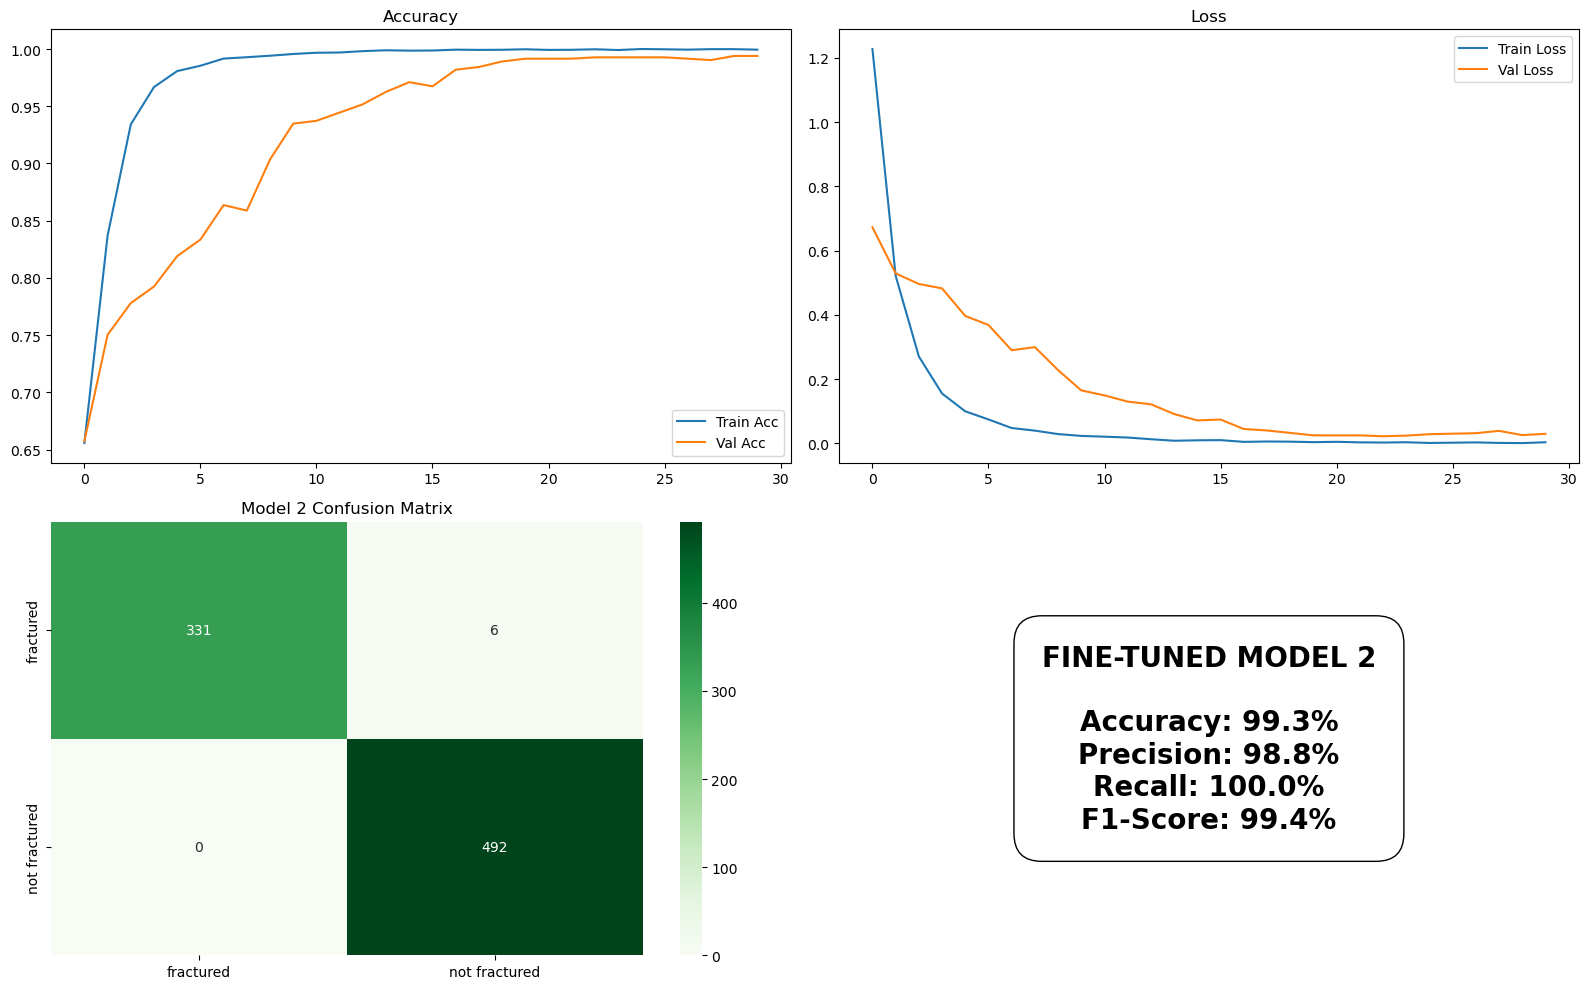

In [3]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import ImageFile
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, applications
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

# --- 1. SETTINGS & SAFETY ---
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True 

root_path = r'Bone Fracture\Bone_Fracture_Binary_Classification\Bone_Fracture_Binary_Classification'
train_dir = os.path.join(root_path, 'train')
val_dir = os.path.join(root_path, 'val')

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

# --- 2. SINGLE LINE PROGRESS CALLBACK ---
class CleanProgress(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\r🚀 Model 2 Fine-Tuning: Epoch {epoch+1}/{self.params['epochs']} "
              f"| Loss: {logs['loss']:.4f} | Acc: {logs['accuracy']:.4f} "
              f"| Val Loss: {logs['val_loss']:.4f}", end="")

# --- 3. DATA PREP (Gentle Augmentation) ---
train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, brightness_range=[0.8, 1.2])
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

# --- 4. BALANCED WEIGHTS ---
labels = (train_gen.class_indices)
f_idx = next(idx for name, idx in labels.items() if 'fracture' in name.lower())
n_idx = next(idx for name, idx in labels.items() if 'not' in name.lower() or 'normal' in name.lower())
weights = {f_idx: 5.0, n_idx: 1.0} # Lowered from 10.0 to 5.0 to reduce False Positives

# --- 5. MODEL ARCHITECTURE (Fine-Tuning Mode) ---
base_model = applications.MobileNetV2(input_shape=(150, 150, 3), include_top=False, weights='imagenet')

# UNFREEZE THE BRAIN: We allow the model to learn medical details
base_model.trainable = True 

model_2 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

# CRITICAL: Using a VERY small learning rate (0.00001) for fine-tuning
model_2.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])

# --- 6. CALLBACKS ---
checkpoint = ModelCheckpoint('best_bone_model_v2.keras', save_best_only=True, monitor='val_loss')
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# --- 7. TRAINING ---
print("🚀 Starting Model 2... This may take longer but will be much smarter.")
history = model_2.fit(
    train_gen, epochs=100, validation_data=val_gen,
    class_weight=weights, verbose=0, callbacks=[CleanProgress(), early_stop, checkpoint] 
)
print("\n✅ TRAINING COMPLETE. File 'best_bone_model_v2.keras' is ready for export.")

# --- 8. DASHBOARD ---
def generate_advanced_report(model, history, val_gen, labels_dict):
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 2)
    
    # Graphs
    ax1 = fig.add_subplot(gs[0, 0]); ax1.plot(history.history['accuracy'], label='Train Acc'); ax1.plot(history.history['val_accuracy'], label='Val Acc'); ax1.set_title('Accuracy'); ax1.legend()
    ax2 = fig.add_subplot(gs[0, 1]); ax2.plot(history.history['loss'], label='Train Loss'); ax2.plot(history.history['val_loss'], label='Val Loss'); ax2.set_title('Loss'); ax2.legend()

    # Metrics
    val_gen.reset()
    preds_prob = model.predict(val_gen, verbose=0)
    y_pred = (preds_prob > 0.5).astype(int).reshape(-1)
    y_true = val_gen.classes
    cm = confusion_matrix(y_true, y_pred)
    acc, pre, rec, f1 = (y_pred == y_true).mean(), precision_score(y_true, y_pred, zero_division=0), recall_score(y_true, y_pred, zero_division=0), f1_score(y_true, y_pred, zero_division=0)

    # Confusion Matrix
    ax3 = fig.add_subplot(gs[1, 0]); sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax3, xticklabels=labels_dict.keys(), yticklabels=labels_dict.keys()); ax3.set_title('Model 2 Confusion Matrix')

    # Metric Card
    ax4 = fig.add_subplot(gs[1, 1]); ax4.axis('off')
    stats = f"FINE-TUNED MODEL 2\n\nAccuracy: {acc:.1%}\nPrecision: {pre:.1%}\nRecall: {rec:.1%}\nF1-Score: {f1:.1%}"
    ax4.text(0.5, 0.5, stats, ha='center', va='center', fontsize=20, fontweight='bold', bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=1'))
    plt.tight_layout(); plt.show()

generate_advanced_report(model_2, history, val_gen, labels)